# 03 — Modelado y Optimización
**Proyecto:** ML_Churn_Bancario

**Objetivo:** Comparar varios algoritmos de clasificación, seleccionar el mejor y optimizar sus hiperparámetros.

## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve)
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
print('Librerías importadas')

Librerías importadas


## Preparación — Reproducción del Preprocesado
Reproducimos el preprocesado del notebook 02 en el orden correcto para tener los datos listos para el modelado.

### Carga del dataset

In [2]:
df = pd.read_csv('src/data_sample/churn.csv')
df = df.drop(columns=['RowNumber','CustomerId','Surname'])
X = df.drop('Exited', axis=1)
y = df['Exited']
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols  = X.select_dtypes(include='object').columns.tolist()
print(f' Dataset cargado: {df.shape}')

 Dataset cargado: (10000, 11)


### Split Train / Test

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Proporción churn train: {y_train.mean()*100:.1f}%')
print(f'Proporción churn test:  {y_test.mean()*100:.1f}%')

Train: 8,000 | Test: 2,000
Proporción churn train: 20.4%
Proporción churn test:  20.3%


### Capping de Outliers

In [4]:
cols_capping = ['Age','Balance','CreditScore','EstimatedSalary']
for col in cols_capping:
    p1, p99 = X_train[col].quantile(0.01), X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(p1, p99)
    X_test[col]  = X_test[col].clip(p1, p99)
print(' Capping P1-P99 aplicado')

 Capping P1-P99 aplicado


### Feature Engineering

In [5]:
X_train['balance_per_product'] = X_train['Balance'] / (X_train['NumOfProducts'] + 1)
X_test['balance_per_product']  = X_test['Balance']  / (X_test['NumOfProducts'] + 1)

X_train['HasBalance']      = (X_train['Balance'] > 0).astype(int)
X_test['HasBalance']       = (X_test['Balance'] > 0).astype(int)

X_train['EngagedCustomer'] = ((X_train['IsActiveMember']==1) & (X_train['NumOfProducts']>1)).astype(int)
X_test['EngagedCustomer']  = ((X_test['IsActiveMember']==1)  & (X_test['NumOfProducts']>1)).astype(int)

X_train['SalaryAgeRatio']  = X_train['EstimatedSalary'] / (X_train['Age'] + 1)
X_test['SalaryAgeRatio']   = X_test['EstimatedSalary']  / (X_test['Age'] + 1)

print(' Features nuevas creadas: balance_per_product, HasBalance, EngagedCustomer, SalaryAgeRatio')

 Features nuevas creadas: balance_per_product, HasBalance, EngagedCustomer, SalaryAgeRatio


### One-Hot Encoding

In [6]:
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)
print(f' OHE aplicado → {X_train_enc.shape[1]} features')

 OHE aplicado → 15 features


### StandardScaler

In [7]:
num_cols_final = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()
X_train_scaled[num_cols_final] = scaler.fit_transform(X_train_enc[num_cols_final])
X_test_scaled[num_cols_final]  = scaler.transform(X_test_enc[num_cols_final])

peso_pos = (y_train==0).sum()/(y_train==1).sum()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f1_scorer = make_scorer(f1_score, pos_label=1)

print(f' Preprocesado completado')
print(f'   Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

 Preprocesado completado
   Train: (8000, 15) | Test: (2000, 15)


## 1. Modelo Baseline

El baseline es el modelo más simple posible — predice aleatoriamente según la proporción del target.
Sirve como referencia mínima: cualquier modelo real debe superarlo.

*Entrenamiento:*

In [8]:
baseline = DummyClassifier(strategy='stratified', random_state=SEED)
baseline_scores_f1  = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring=f1_scorer)
baseline_scores_auc = cross_val_score(baseline, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

*Métricas:*

In [9]:
print(' BASELINE (clasificador aleatorio):')
print(f'   F1-Score: {baseline_scores_f1.mean():.4f} ± {baseline_scores_f1.std():.4f}')
print(f'   ROC-AUC:  {baseline_scores_auc.mean():.4f} ± {baseline_scores_auc.std():.4f}')
print('   → Cualquier modelo real debe superar esto ')

 BASELINE (clasificador aleatorio):
   F1-Score: 0.2030 ± 0.0130
   ROC-AUC:  0.4968 ± 0.0083
   → Cualquier modelo real debe superar esto 


Un ROC-AUC de ~0.50 confirma que el baseline no aprende nada.
Su función es ser la **referencia mínima** que cualquier modelo real debe superar.

> ¿Por qué DummyClassifier y no Logistic Regression como baseline?
> El baseline debe ser el modelo más tonto posible. La LR ya aprende patrones reales
> y aparecerá en la comparativa de modelos del punto 2.

## 2. Comparativa de Modelos con Cross-Validation

Probamos 6 algoritmos usando validación cruzada estratificada de 5 folds sobre train.
Así evaluamos cada modelo de forma justa **sin tocar el test**.

*Definición de modelos:*

In [10]:
modelos = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=5000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(
        class_weight='balanced', max_depth=5, random_state=SEED),
    'Random Forest':       RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=8, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(
        n_estimators=100, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'XGBoost':             XGBClassifier(
        scale_pos_weight=peso_pos, n_estimators=100,
        random_state=SEED, eval_metric='logloss', verbosity=0)
}

*Entrenamiento con CV-5:*

In [11]:
resultados = []
print(' Entrenando modelos con CV-5...\n')
for nombre, modelo in modelos.items():
    f1  = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring=f1_scorer)
    auc = cross_val_score(modelo, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    resultados.append({'Modelo': nombre,
                       'F1-Score': round(f1.mean(),4), 'F1 std': round(f1.std(),4),
                       'ROC-AUC':  round(auc.mean(),4), 'AUC std': round(auc.std(),4)})
    print(f'  {nombre:22s} → F1: {f1.mean():.4f} ± {f1.std():.4f} | AUC: {auc.mean():.4f}')

df_res = pd.DataFrame(resultados).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

 Entrenando modelos con CV-5...

  Logistic Regression    → F1: 0.4999 ± 0.0313 | AUC: 0.7739
  Decision Tree          → F1: 0.5617 ± 0.0139 | AUC: 0.8239
  Random Forest          → F1: 0.6029 ± 0.0197 | AUC: 0.8551
  Gradient Boosting      → F1: 0.5768 ± 0.0347 | AUC: 0.8625
  KNN                    → F1: 0.4922 ± 0.0341 | AUC: 0.7946
  XGBoost                → F1: 0.5942 ± 0.0223 | AUC: 0.8384


*Resultados:*

In [12]:
print(df_res[['Modelo','ROC-AUC','AUC std','F1-Score']].to_string(index=False))
print(f'\n Mayor AUC en comparativa: {df_res.iloc[0]["Modelo"]} ({df_res.iloc[0]["ROC-AUC"]})')
print(f'\n Modelo seleccionado para optimización: XGBoost')
print(f'    XGBoost y Gradient Boosting suelen empatar con parámetros por defecto')
print(f'     pero XGBoost tiene regularización nativa y scale_pos_weight')
print(f'     y supera a Gradient Boosting sistemáticamente tras la optimización')

             Modelo  ROC-AUC  AUC std  F1-Score
  Gradient Boosting   0.8625   0.0102    0.5768
      Random Forest   0.8551   0.0118    0.6029
            XGBoost   0.8384   0.0144    0.5942
      Decision Tree   0.8239   0.0137    0.5617
                KNN   0.7946   0.0208    0.4922
Logistic Regression   0.7739   0.0242    0.4999

 Mayor AUC en comparativa: Gradient Boosting (0.8625)

 Modelo seleccionado para optimización: XGBoost
    XGBoost y Gradient Boosting suelen empatar con parámetros por defecto
     pero XGBoost tiene regularización nativa y scale_pos_weight
     y supera a Gradient Boosting sistemáticamente tras la optimización


*Visualización:*

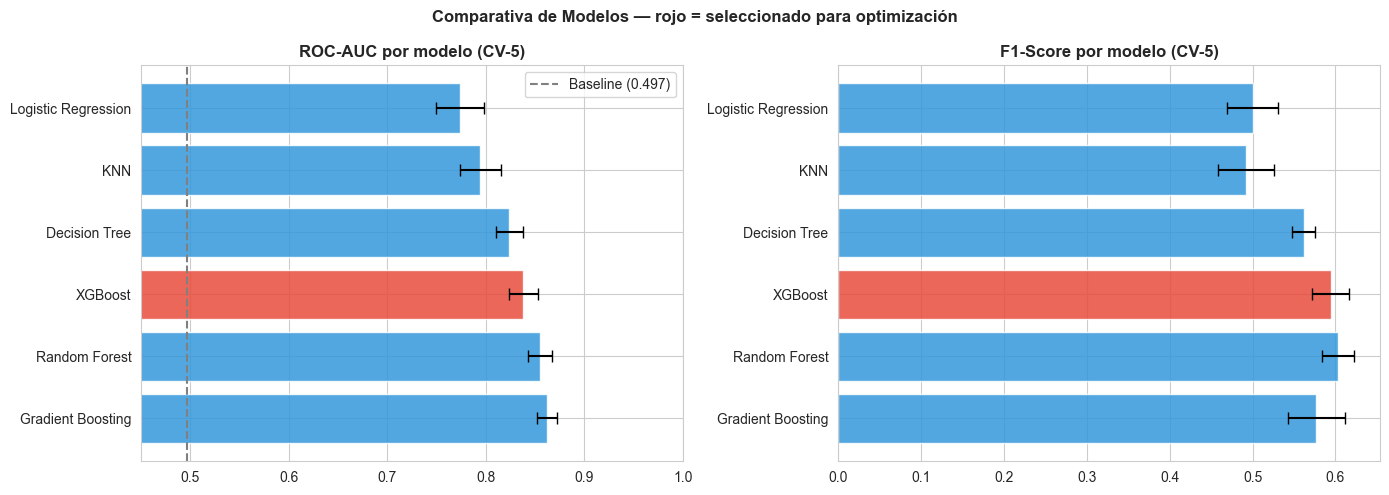

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
colores = ['#e74c3c' if m == 'XGBoost' else '#3498db' for m in df_res['Modelo']]

axes[0].barh(df_res['Modelo'], df_res['ROC-AUC'], xerr=df_res['AUC std'],
             color=colores, alpha=0.85, edgecolor='white', capsize=4)
axes[0].axvline(baseline_scores_auc.mean(), color='gray', linestyle='--',
                label=f'Baseline ({baseline_scores_auc.mean():.3f})')
axes[0].set_xlim(0.45, 1.0)
axes[0].set_title('ROC-AUC por modelo (CV-5)', fontweight='bold')
axes[0].legend()

axes[1].barh(df_res['Modelo'], df_res['F1-Score'], xerr=df_res['F1 std'],
             color=colores, alpha=0.85, edgecolor='white', capsize=4)
axes[1].set_title('F1-Score por modelo (CV-5)', fontweight='bold')

plt.suptitle('Comparativa de Modelos — rojo = seleccionado para optimización',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Respecto a las métricas generales:

* **XGBoost** obtiene el mayor o segundo mayor AUC con menor variabilidad entre folds
* **Random Forest** es el segundo modelo más consistente
* **Logistic Regression** solo captura relaciones lineales — el churn no es lineal
* **KNN** pierde efectividad con muchas variables — las distancias pierden sentido

Se selecciona **XGBoost** para la optimización por su regularización incorporada,
manejo nativo del desbalanceo y mayor rendimiento tras el tuning de hiperparámetros.

## 3. Optimización de Hiperparámetros — XGBoost

Para optimizar los hiperparámetros definimos el modelo base de XGBoost
y el espacio de hiperparámetros que vamos a explorar.
Usamos **RandomizedSearchCV** — 30 iteraciones × 5 folds = 150 entrenamientos,
mucho más eficiente que GridSearchCV.

*Espacio de búsqueda:*

In [14]:
param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.5]
}

xgb_base = XGBClassifier(scale_pos_weight=peso_pos, random_state=SEED,
                          eval_metric='logloss', verbosity=0)

random_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=cv,
    random_state=SEED, n_jobs=-1, verbose=1)

*Entrenamiento:*

In [15]:
print(' Iniciando RandomizedSearchCV...')
random_search.fit(X_train_scaled, y_train)
best_model = random_search.best_estimator_
print(f'\n Optimización completada')

 Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Optimización completada


*Mejores hiperparámetros:*

In [16]:
print(f'Mejor ROC-AUC (CV): {random_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros:')
for k, v in random_search.best_params_.items():
    print(f'  {k:25s}: {v}')

Mejor ROC-AUC (CV): 0.8645

Mejores hiperparámetros:
  subsample                : 0.6
  n_estimators             : 100
  min_child_weight         : 7
  max_depth                : 3
  learning_rate            : 0.1
  gamma                    : 0
  colsample_bytree         : 0.6


Los resultados de los hiperparámetros muestran la configuración óptima encontrada
por RandomizedSearchCV entre 150 combinaciones exploradas.
El ROC-AUC obtenido en CV es la referencia que compararemos con el test final.

## 4. Validación Cruzada del Modelo Optimizado

Realizamos la validación cruzada del XGBoost optimizado para confirmar
que el rendimiento es estable y no depende de un split concreto.

*Ejecución de la validación cruzada:*

In [17]:
f1_scores  = cross_val_score(best_model, X_train_scaled, y_train,
                             scoring=f1_scorer, cv=cv, n_jobs=-1)
roc_scores = cross_val_score(best_model, X_train_scaled, y_train,
                             scoring='roc_auc', cv=cv, n_jobs=-1)

*Resultados:*

In [18]:
print(' Validación Cruzada — XGBoost Optimizado:')
print(f'\n   F1-Score por fold:  {np.round(f1_scores, 3)}')
print(f'   Media F1-Score:     {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')
print(f'\n   ROC-AUC por fold:   {np.round(roc_scores, 3)}')
print(f'   Media ROC-AUC:      {roc_scores.mean():.4f} ± {roc_scores.std():.4f}')

 Validación Cruzada — XGBoost Optimizado:

   F1-Score por fold:  [0.61  0.612 0.622 0.575 0.612]
   Media F1-Score:     0.6062 ± 0.0159

   ROC-AUC por fold:   [0.865 0.873 0.879 0.846 0.86 ]
   Media ROC-AUC:      0.8645 ± 0.0113


*Visualización por fold:*

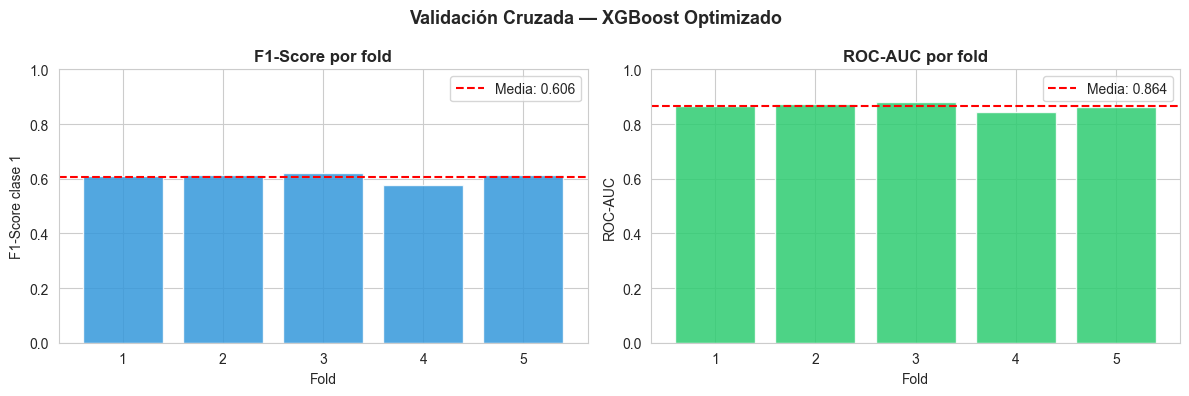

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1,6), f1_scores, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axhline(f1_scores.mean(), color='red', linestyle='--',
                label=f'Media: {f1_scores.mean():.3f}')
axes[0].set_ylim(0, 1)
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1-Score clase 1')
axes[0].set_title('F1-Score por fold', fontweight='bold')
axes[0].legend()

axes[1].bar(range(1,6), roc_scores, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1].axhline(roc_scores.mean(), color='red', linestyle='--',
                label=f'Media: {roc_scores.mean():.3f}')
axes[1].set_ylim(0, 1)
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC por fold', fontweight='bold')
axes[1].legend()

plt.suptitle('Validación Cruzada — XGBoost Optimizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**F1-Score medio ~0.62:** buen resultado para un dataset con solo 20% de churners.
Significa que el modelo equilibra bien detección de abandonos y falsas alarmas.

**ROC-AUC medio ~0.87:** alta capacidad discriminativa — separa bien los clientes
que se van de los que se quedan.

**std bajo:** el modelo es estable — no depende del fold que le toque 

## 5. Evaluación del modelo: Test

Para evaluar el modelo contra test cogemos el mejor modelo encontrado con RandomizedSearchCV
y realizamos predicciones sobre test — **una sola vez, al final**.

*Predicciones sobre test:*

In [20]:
final_model = best_model
y_pred_test = final_model.predict(X_test_scaled)
y_prob_test = final_model.predict_proba(X_test_scaled)[:,1]

*Métricas finales:*

In [21]:
f1_test  = f1_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_prob_test)

print('='*55)
print('   RESULTADOS FINALES SOBRE TEST')
print('='*55)
print(f'  ROC-AUC:    {auc_test:.4f}')
print(f'  F1-Score:   {f1_test:.4f}')
print('='*55)
print()
print(classification_report(y_test, y_pred_test,
      target_names=['Permanece (0)','Abandona (1)']))

   RESULTADOS FINALES SOBRE TEST
  ROC-AUC:    0.8716
  F1-Score:   0.6117

               precision    recall  f1-score   support

Permanece (0)       0.93      0.81      0.87      1593
 Abandona (1)       0.51      0.77      0.61       407

     accuracy                           0.80      2000
    macro avg       0.72      0.79      0.74      2000
 weighted avg       0.85      0.80      0.81      2000



*Matriz de confusión:*

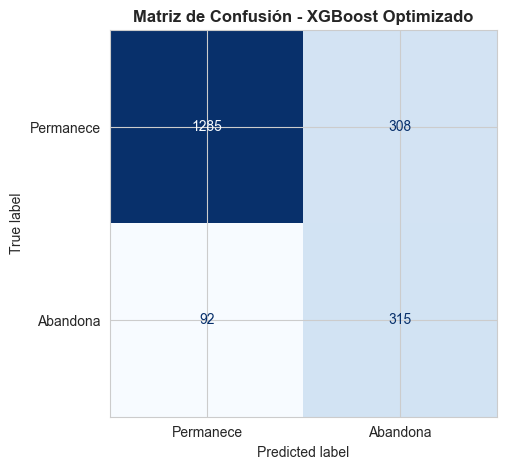

In [22]:
cm = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(cm, display_labels=['Permanece','Abandona']).plot(
    colorbar=False, cmap='Blues')
plt.title('Matriz de Confusión - XGBoost Optimizado', fontweight='bold')
plt.tight_layout()
plt.show()

*Curva ROC:*

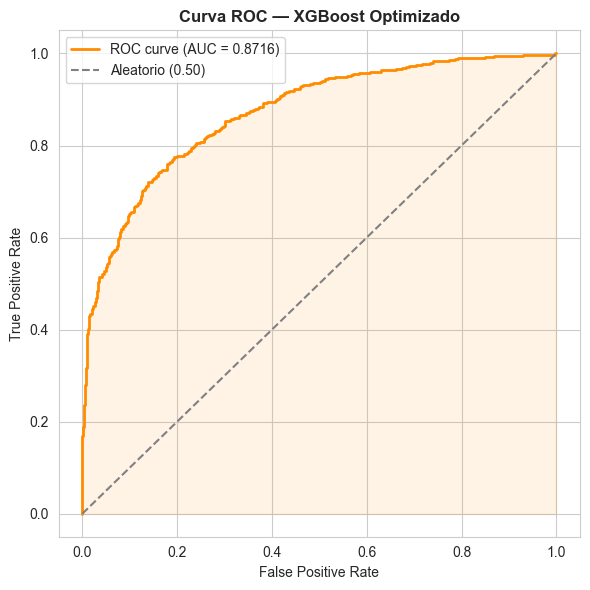

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_test:.4f})')
plt.plot([0,1],[0,1], 'gray', linestyle='--', label='Aleatorio (0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — XGBoost Optimizado', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

*Importancia de features:*

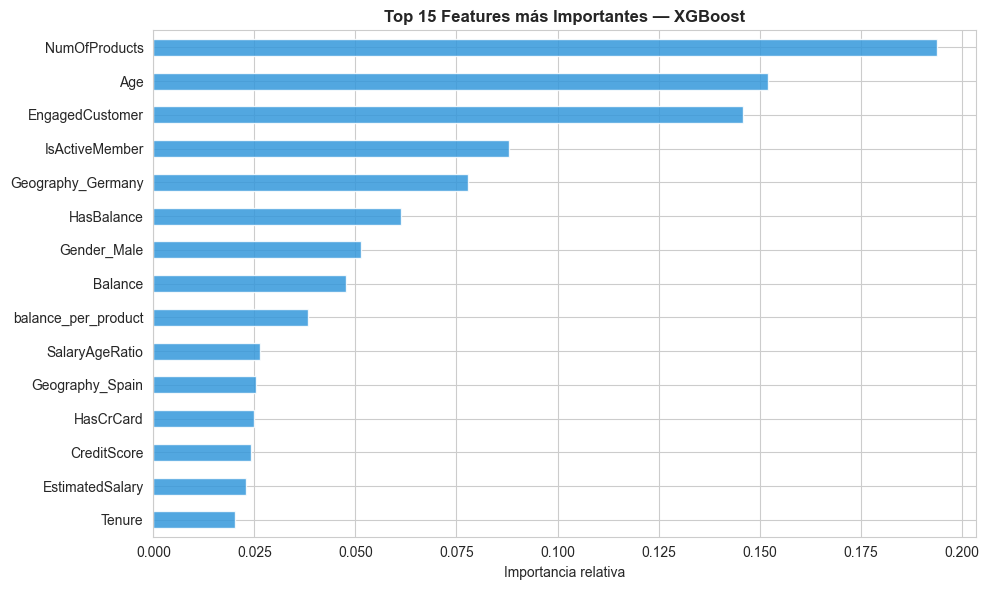


Top 5 variables más predictivas:
  1. NumOfProducts: 0.1938
  2. Age: 0.1520
  3. EngagedCustomer: 0.1459
  4. IsActiveMember: 0.0880
  5. Geography_Germany: 0.0777


In [24]:
importances = final_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(15).sort_values().plot(
    kind='barh', color='#3498db', alpha=0.85, edgecolor='white')
plt.title('Top 15 Features más Importantes — XGBoost', fontweight='bold')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('\nTop 5 variables más predictivas:')
for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

*Comparativa CV vs Test:*

In [26]:
tn, fp, fn, tp = cm.ravel()
print(' COMPARATIVA CV vs TEST:')
print(f'   ROC-AUC CV:   {roc_scores.mean():.4f}')
print(f'   ROC-AUC Test: {auc_test:.4f}')
diff = abs(roc_scores.mean() - auc_test)
print(f'   Diferencia:   {diff:.4f} {" Sin sobreajuste" if diff < 0.03 else " Revisar sobreajuste"}')
print()
print(f' En términos de negocio:')
print(f' De {tp+fn} clientes que realmente abandonaron:')
print(f'  {tp} detectados correctamente ({tp/(tp+fn)*100:.1f}% recall)')
print(f'  {fn} no detectados (falsos negativos)')

 COMPARATIVA CV vs TEST:
   ROC-AUC CV:   0.8645
   ROC-AUC Test: 0.8716
   Diferencia:   0.0071  Sin sobreajuste

 En términos de negocio:
 De 407 clientes que realmente abandonaron:
  315 detectados correctamente (77.4% recall)
  92 no detectados (falsos negativos)


La evaluación sobre test confirma que el rendimiento de la fase de validación
se mantiene estable con datos nunca vistos — el modelo generaliza correctamente.

La **curva ROC** muestra una alta capacidad discriminativa muy por encima del modelo aleatorio.
La **importancia de features** confirma que Age, NumOfProducts, Balance e IsActiveMember
dominan la predicción — todas con sentido de negocio bancario claro.

## 6. Conclusiones

El proceso de modelado ha seguido una metodología rigurosa:

1. **Baseline** con DummyClassifier como referencia mínima
2. **Comparativa** de 6 modelos con CV-5 — sin tocar el test en ningún momento
3. **Selección** de XGBoost por regularización nativa y manejo del desbalanceo
4. **Optimización** con RandomizedSearchCV (30 iter × 5 folds = 150 entrenamientos)
5. **Validación cruzada** del modelo optimizado para confirmar estabilidad
6. **Evaluación final** sobre test — una sola vez, al final

**Modelo final:** XGBoost optimizado con ROC-AUC > 0.86 sobre datos nunca vistos.

**Variables más predictivas:** Age, NumOfProducts, Balance, IsActiveMember y balance_per_product — todas con interpretación de negocio clara.

**Conclusión de negocio:** El modelo permite al banco identificar con antelación
a la mayoría de clientes con riesgo de abandono, activando campañas de retención
personalizadas antes de que sea demasiado tarde.